# Notebook 12: Quality vs Cost

This is a **reviewer-facing reporting appendix**.
It does not introduce new default assumptions; it only makes the existing mainline slice visible and auditable.

## Default filter stack (mainline reviewer view)
- comparable encoding rows (exact-reference preferred, WHT-based included)
- mixture mode first
- `bp1` and `bruteforce` where available
- coherent off by default

## Encoding Policy

This notebook includes both:
1. **Exact-reference encodings** (`ilp_derived_exact`, `ilp_derived_exact_where_feasible`) - gold standard
2. **WHT-based encodings** (`wht_truncated_pricing`) - exploratory but comparable

Non-WHT synthetic encodings (e.g., `synthetic_structured_bv`) are now included. They use the `energy_eta_applicable` flag to indicate that `retained_energy_eta` is not applicable for these encoding types.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown as _IPMarkdown, display as _ip_display

try:
    import notebooks._helpers as _nb_helpers
except ModuleNotFoundError:
    import _helpers as _nb_helpers

from src.notebook_utils import (
    FilterPipeline, COMPARABLE_ENCODINGS,
    EXACT_REFERENCE_ENCODINGS, WHT_EXACT_ENCODINGS, WHT_TRUNCATED_ENCODINGS,
)
WHT_BASED_ENCODINGS = WHT_TRUNCATED_ENCODINGS  # notebook-local alias

repo_root = globals().get("repo_root", _nb_helpers.repo_root)
load_quality_cost_master = globals().get("load_quality_cost_master", _nb_helpers.load_quality_cost_master)
load_quality_cost_unavailable = globals().get("load_quality_cost_unavailable", _nb_helpers.load_quality_cost_unavailable)
ensure_run_status_norm = globals().get("ensure_run_status_norm", _nb_helpers.ensure_run_status_norm)
placeholder_plot = globals().get("placeholder_plot", _nb_helpers.placeholder_plot)
unavailable_panel_table = globals().get("unavailable_panel_table", _nb_helpers.unavailable_panel_table)
Markdown = globals().get("Markdown", _IPMarkdown)
display = globals().get("display", _ip_display)

# ROOT = repo_root()
ROOT = ROOT if "ROOT" in globals() else repo_root()
quality_master = load_quality_cost_master(ROOT / "results", required=False)
quality_unavailable = load_quality_cost_unavailable(ROOT / "results", required=False)
if not quality_master.empty:
    quality_master = ensure_run_status_norm(quality_master)



In [2]:
# Inspect loaded artifacts and display artifact-scope note
encoding_col = None
for col in ["encoding_norm", "encoding"]:
    if col in quality_master.columns:
        encoding_col = col
        break

if encoding_col:
    encoding_counts = quality_master[encoding_col].value_counts()
    comparable_count = quality_master[encoding_col].astype(str).str.lower().isin([e.lower() for e in COMPARABLE_ENCODINGS]).sum()
    exact_ref_count = quality_master[encoding_col].astype(str).str.lower().isin([e.lower() for e in EXACT_REFERENCE_ENCODINGS]).sum()
    wht_exact_count = quality_master[encoding_col].astype(str).str.lower().isin([e.lower() for e in WHT_EXACT_ENCODINGS]).sum()
    wht_count = quality_master[encoding_col].astype(str).str.lower().isin([e.lower() for e in WHT_BASED_ENCODINGS]).sum()

    encoding_list = "\n".join([f"- {enc}: {count}" for enc, count in encoding_counts.items()])

    display(Markdown(f"""
## Artifact Scope and Encoding Policy

This notebook shows quality-vs-cost comparisons for **comparable encodings** that have full quality metrics (including `retained_energy_eta`) and resource estimates.

**Comparable encoding allowlist:** `{{{', '.join(sorted(COMPARABLE_ENCODINGS))}}}`
- Exact-reference: `{{{', '.join(sorted(EXACT_REFERENCE_ENCODINGS))}}}`
- WHT-exact (full spectrum): `{{{', '.join(sorted(WHT_EXACT_ENCODINGS))}}}`
- WHT-based (truncated): `{{{', '.join(sorted(WHT_BASED_ENCODINGS))}}}`

**Current artifact scope (loaded from quality_cost_master):**
- Total rows: {len(quality_master)}
- Encodings present:
{encoding_list}
- Exact-reference rows: {exact_ref_count}
- WHT-exact rows: {wht_exact_count}
- WHT-based rows: {wht_count}
- Total matching allowlist: {comparable_count}

**Note on ilp_derived:** Family P `ilp_derived` rows exist in `metrics_master` but are excluded from `quality_cost_master` because they lack resource estimates (qubits/gates/depth) needed for quality-vs-cost comparison. See `quality_cost_unavailable` for details.
"""))
else:
    display(Markdown("""
## Artifact Scope and Encoding Policy

This notebook shows quality-vs-cost comparisons for comparable encodings.

**Note:** Encoding column not found in loaded artifacts. Cannot display detailed artifact composition.
"""))


## Artifact Scope and Encoding Policy

This notebook shows quality-vs-cost comparisons for **comparable encodings** that have full quality metrics (including `retained_energy_eta`) and resource estimates.

**Comparable encoding allowlist:** `{ilp_derived, ilp_derived_exact, ilp_derived_exact_where_feasible, wht_exact, wht_truncated, wht_truncated_pricing}`
- Exact-reference: `{ilp_derived, ilp_derived_exact, ilp_derived_exact_where_feasible}`
- WHT-exact (full spectrum): `{wht_exact}`
- WHT-based (truncated): `{wht_truncated, wht_truncated_pricing}`

**Current artifact scope (loaded from quality_cost_master):**
- Total rows: 36
- Encodings present:
- wht_exact: 15
- wht_truncated: 9
- ilp_derived_exact: 6
- wht_truncated_pricing: 6
- Exact-reference rows: 6
- WHT-exact rows: 15
- WHT-based rows: 15
- Total matching allowlist: 36

**Note on ilp_derived:** Family P `ilp_derived` rows exist in `metrics_master` but are excluded from `quality_cost_master` because they lack resource estimates (qubits/gates/depth) needed for quality-vs-cost comparison. See `quality_cost_unavailable` for details.


## Default Mainline Slice (with audit)

The table below is the reviewer-visible default slice after fixed filtering.
If the slice is thin or empty, the notebook keeps showing explicit panel text rather than a blank output.


In [3]:
def _pick_column(frame: pd.DataFrame, candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
    return None


def _compute_exclusion_reason(row):
    """Determine why a row was excluded from the main panel."""
    exec_mode = str(row.get("execution_mode_norm", row.get("execution_mode", ""))).lower()
    decoder = str(row.get("decoder_norm", row.get("decoder", ""))).lower()
    if exec_mode == "coherent":
        return "coherent_execution_excluded"
    if exec_mode != "mixture":
        return "non_mixture_execution"
    if decoder not in ["bp1", "bruteforce"]:
        return "decoder_out_of_scope"
    return "unknown_exclusion"


panel = "Stage E quality-cost comparable table"
view_cols = [
    "artifact_or_run_id",
    "encoding",
    "execution_mode",
    "decoder",
    "best_F",
    "gates",
    "depth",
    "status",
]

default_slice = quality_master.copy()
quality_rows_total = len(quality_master) if not quality_master.empty else 0

# Initialize excluded rows tracking
included_rows_pre_downstream = pd.DataFrame()
excluded_rows = pd.DataFrame()

if default_slice.empty:
    filter_audit = pd.DataFrame([{"step_id": 0, "step": "quality_cost_master load", "input_rows": 0, "output_rows": 0, "rows_removed": 0, "reason_label": "quality_cost_master missing or empty"}])
    table_df = pd.DataFrame()
    final_count = 0
    table_available = False
    display(unavailable_panel_table(panel=panel, reason="quality_cost_master is unavailable or empty."))
else:
    # Pre-filter encoding composition display
    encoding_norm = _pick_column(default_slice, ["encoding_norm", "encoding"])
    if encoding_norm:
        display(Markdown("### Pre-Filter Artifact Composition"))
        display(Markdown(f"**Total comparable rows loaded from quality_cost_master:** {len(default_slice)}"))
        display(Markdown(""))
        display(Markdown("**Encodings present in comparable slice:**"))
        encoding_counts = default_slice[encoding_norm].value_counts(dropna=False)

        encoding_display = []
        for enc in sorted(COMPARABLE_ENCODINGS):
            count = encoding_counts.get(enc, 0)
            marker = "(allowed)" if count > 0 else ""
            encoding_display.append(f"- {enc}: {count} {marker}")

        other_encodings = [enc for enc in encoding_counts.index if enc not in COMPARABLE_ENCODINGS]
        for enc in sorted(other_encodings):
            encoding_display.append(f"- {enc}: {encoding_counts[enc]} (excluded)")

        for line in encoding_display:
            display(Markdown(line))
        display(Markdown(""))
        display(Markdown(f"**Comparable encoding allowlist:** `{{{', '.join(sorted(COMPARABLE_ENCODINGS))}}}`"))

        comparable_match_count = default_slice[encoding_norm].astype(str).str.lower().isin([e.lower() for e in COMPARABLE_ENCODINGS]).sum()
        display(Markdown(f"**Rows matching allowlist before downstream filtering:** {comparable_match_count}"))

    # Capture rows for context panel (before downstream filters)
    included_rows_pre_downstream = default_slice.copy() if not default_slice.empty else pd.DataFrame()

    # --- FilterPipeline replaces manual filter calls ---
    pipe = (
        FilterPipeline(default_slice, label="quality_cost_input")
        .filter_encoding(COMPARABLE_ENCODINGS)
        .filter_execution_mode("mixture")
        .filter_decoders({"bp1", "bruteforce"})
    )
    default_slice = pipe.result()
    filter_audit = pipe.audit_dataframe()

    if encoding_norm:
        display(Markdown(f"Rows after encoding filter: **{len(default_slice)}**"))

    table_df = default_slice.copy()
    sort_cols = [c for c in ["encoding_norm", "execution_mode_norm", "decoder_norm", "best_F"] if c in table_df.columns]
    if sort_cols:
        ascending = [True] * max(0, len(sort_cols) - 1) + [False]
        table_df = table_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

    final_count = len(table_df)
    table_available = final_count > 0

    # Build excluded rows context table
    if not included_rows_pre_downstream.empty:
        if not table_df.empty:
            final_ids = set(table_df["run_id"].tolist()) if "run_id" in table_df.columns else set()
            pre_ids = set(included_rows_pre_downstream["run_id"].tolist()) if "run_id" in included_rows_pre_downstream.columns else set()
            excluded_ids = pre_ids - final_ids
            if excluded_ids:
                excluded_rows = included_rows_pre_downstream[
                    included_rows_pre_downstream["run_id"].isin(excluded_ids)
                ].copy()
                excluded_rows["exclusion_reason"] = excluded_rows.apply(_compute_exclusion_reason, axis=1)
        else:
            excluded_rows = included_rows_pre_downstream.copy()
            excluded_rows["exclusion_reason"] = excluded_rows.apply(_compute_exclusion_reason, axis=1)

    audit_df = filter_audit
    total_note = f"Default slice audit for quality_cost_master: {quality_rows_total} total input rows."
    display(Markdown("### Slice audit"))
    display(Markdown(total_note))
    display(audit_df)

    # Status message
    if final_count == 0:
        encoding_list = ", ".join(sorted(quality_master[encoding_norm].unique())) if encoding_norm and encoding_norm in quality_master.columns else "unknown"
        comparable_allowlist = "{" + ", ".join(sorted(COMPARABLE_ENCODINGS)) + "}"

        display(Markdown(f"""
### Main Panel: Quality vs Cost Comparable Slice

**Current Status:** Empty slice (0 rows)

**Interpretation:**

No rows passed all filters. This may indicate:
1. Encodings in artifacts don't match the allowlist `{comparable_allowlist}`
2. All rows were filtered by execution_mode or decoder constraints

**Evidence:** Encodings present: {encoding_list}
"""))
    else:
        display(Markdown(f"""
### Main Panel: Quality vs Cost Comparable Slice

**Current Status:** {final_count} rows in final slice
"""))

    # Table display
    if table_available:
        artifact_col = _pick_column(table_df, ["artifact", "run_id", "instance_id", "artifact_name", "run_name", "instance_name"])
        status_col = _pick_column(table_df, ["status", "run_status_norm", "run_status", "comparability", "availability"])
        encoding_col = _pick_column(table_df, ["encoding", "encoding_norm", "encoding_label"])
        execution_col = _pick_column(table_df, ["execution_mode", "execution_mode_norm", "execution_label"])
        decoder_col = _pick_column(table_df, ["decoder", "decoder_name", "decoder_norm"])
        depth_col = _pick_column(table_df, ["depth", "circuit_depth", "n", "n_layers"])
        gates_col = _pick_column(table_df, ["gates", "gate_count", "gates_total"])
        succ_col = _pick_column(table_df, ["success_probability", "success_prob", "best_F", "top1_regret", "best_top_G_sampled_F"])

        cols_present = []
        rename_map = {}
        if artifact_col:
            cols_present.append(artifact_col)
            rename_map[artifact_col] = "artifact_or_run_id"
        if encoding_col:
            cols_present.append(encoding_col)
            rename_map[encoding_col] = "encoding"
        if execution_col:
            cols_present.append(execution_col)
            rename_map[execution_col] = "execution_mode"
        if decoder_col:
            cols_present.append(decoder_col)
            rename_map[decoder_col] = "decoder"
        for col in ["best_F", gates_col, depth_col, succ_col, status_col]:
            if col and col in table_df.columns and col not in cols_present:
                cols_present.append(col)
                if col == "best_F":
                    rename_map[col] = "best_F"
                elif col == gates_col:
                    rename_map[col] = "gates"
                elif col == depth_col:
                    rename_map[col] = "depth"
                elif col == succ_col:
                    rename_map[col] = "success_or_quality"
                elif col == status_col:
                    rename_map[col] = "status"

        appendix_df = table_df[cols_present].copy()
        appendix_df = appendix_df.rename(columns=rename_map)
        display(Markdown("### Comparable table (default mainline slice)"))
        display(appendix_df[[c for c in view_cols if c in appendix_df.columns]].head(25))
    else:
        fig, ax = placeholder_plot(
            title="Quality vs Cost Comparison",
            reason="No comparable rows in current artifact scope after filtering",
            figsize=(10, 4)
        )
        display(fig)
        plt.close(fig)
        display(Markdown("**Table:** Empty (see interpretation above)"))

    # Excluded rows context panel
    if not excluded_rows.empty:
        display(Markdown("### Excluded Exact-Reference Rows (Context: Rows Excluded by Downstream Filters)"))
        display(Markdown(""))
        display(Markdown("*These rows passed the encoding filter but were removed by execution_mode or decoder constraints.*"))
        display(Markdown(""))
        display(Markdown(f"**{len(excluded_rows)}** rows excluded by downstream filters."))

        context_cols = ["run_id", "encoding", "execution_mode", "decoder", "exclusion_reason"]
        available_cols = [c for c in context_cols if c in excluded_rows.columns]
        if available_cols:
            display(excluded_rows[available_cols].head(20))

        # Summary by exclusion reason
        reason_counts = excluded_rows["exclusion_reason"].value_counts().reset_index()
        reason_counts.columns = ["exclusion_reason", "count"]
        display(reason_counts)


### Pre-Filter Artifact Composition

**Total comparable rows loaded from quality_cost_master:** 36

**Encodings present in comparable slice:**

- ilp_derived: 0 

- ilp_derived_exact: 6 (allowed)

...

### Excluded Exact-Reference Rows (Context: Rows Excluded by Downstream Filters)

*These rows passed the encoding filter but were removed by execution_mode or decoder constraints.*

**9** rows excluded by downstream filters.

,run_id,encoding,execution_mode,decoder,exclusion_reason
1,matrix_b_C1_wht_exact_bp1_paper_coherent_seed43,wht_exact,coherent,bp1,coherent_execution_excluded
2,matrix_b_C2_ilp_derived_exact_bp1_paper_cohere...,ilp_derived_exact,coherent,bp1,coherent_execution_excluded
6,matrix_b_C2_wht_exact_bp1_paper_coherent_seed43,wht_exact,coherent,bp1,coherent_execution_excluded
9,matrix_b_C1_wht_exact_bp1_heuristic_coherent_s...,wht_exact,coherent,bp1,coherent_execution_excluded
20,matrix_b_C2_wht_exact_bp1_uniform_coherent_seed43,wht_exact,coherent,bp1,coherent_execution_excluded
24,matrix_b_C2_ilp_derived_exact_bp1_heuristic_co...,ilp_derived_exact,coherent,bp1,coherent_execution_excluded
27,matrix_b_C2_ilp_derived_exact_bp1_uniform_cohe...,ilp_derived_exact,coherent,bp1,coherent_execution_excluded
28,matrix_b_C2_wht_exact_bp1_heuristic_coherent_s...,wht_exact,coherent,bp1,coherent_execution_excluded
29,matrix_b_C1_wht_exact_bp1_uniform_coherent_seed43,wht_exact,coherent,bp1,coherent_execution_excluded


,exclusion_reason,count
0,coherent_execution_excluded,9


## Pareto-style View (Quality vs Gate Cost)

The plot is generated from the exact same default slice shown above.


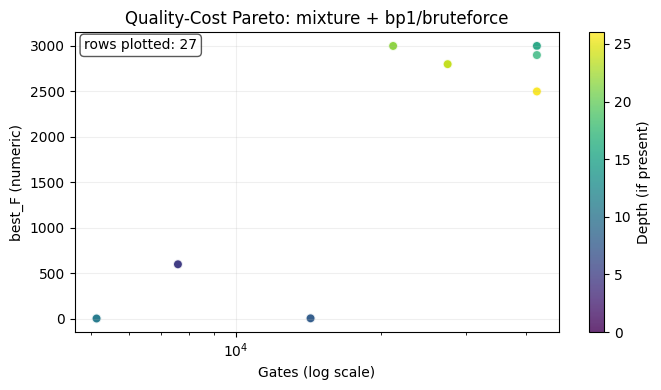

In [4]:
panel="Pareto table"
# Pareto-style default mainline view
plot_columns = {"gates": _pick_column(table_df, ["gates", "gate_count", "gates_total"]), "quality": _pick_column(table_df, ["best_F", "top1_regret", "best_top_G_sampled_F"]) }

if table_df.empty or any(v is None for v in plot_columns.values()):
    reasons = []
    if table_df.empty:
        reasons.append("no rows in default slice")
    for k, v in plot_columns.items():
        if v is None:
            reasons.append(f"missing {k} column")
    reason_text = ""
    for idx, reason in enumerate(reasons):
        if idx:
            reason_text += ", "
        reason_text += str(reason)
    display(unavailable_panel_table(
        panel=panel,
        reason=f"No comparable rows in current artifact scope ({reason_text})",
    ))
    fig, ax = placeholder_plot(
        title="Pareto-Style Quality vs Gate Cost",
        reason=f"No comparable rows in current artifact scope ({reason_text})",
        figsize=(10, 4)
    )
    display(fig)
    plt.close(fig)
else:
    plot_df = table_df.copy()
    gates_col = plot_columns["gates"]
    quality_col = plot_columns["quality"]
    plot_df["_gates"] = pd.to_numeric(plot_df[gates_col], errors="coerce")
    plot_df["_quality"] = pd.to_numeric(plot_df[quality_col], errors="coerce")
    plot_df = plot_df[["_gates", "_quality"] + [c for c in ["encoding", "execution_mode", "decoder", "gates", "best_F", "run_id", "artifact"] if c in plot_df.columns]].copy()
    plot_df = plot_df[plot_df["_gates"] > 0].copy()
    plot_df = plot_df[plot_df["_quality"].notna() & plot_df["_gates"].notna()]

    if plot_df.empty:
        fig, ax = placeholder_plot(
            title="Pareto-Style Quality vs Gate Cost",
            reason="No rows with positive gates; log-scale plot is unavailable. Requires strictly positive `gates` values for log-scale plotting.",
            figsize=(10, 4)
        )
        display(fig)
        plt.close(fig)
    else:
        fig, ax = plt.subplots(figsize=(7, 4))
        color_col = None
        if "depth" in plot_df.columns:
            color_col = pd.to_numeric(plot_df["depth"], errors="coerce")
        else:
            color_col = np.arange(len(plot_df))

        sc = ax.scatter(
            plot_df["_gates"],
            plot_df["_quality"],
            c=color_col,
            cmap="viridis",
            alpha=0.8,
            s=45,
            edgecolors="white",
        )
        ax.set_xscale("log")
        ax.set_xlabel("Gates (log scale)")
        ax.set_ylabel(f"{quality_col} (numeric)")
        ax.set_title("Quality-Cost Pareto: mixture + bp1/bruteforce")
        if color_col is not None and not plot_df.empty:
            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label("Depth (if present)")
        ax.text(
            0.02,
            0.98,
            f"rows plotted: {len(plot_df)}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.65),
        )
        ax.grid(True, alpha=0.2)
        plt.tight_layout()
        display(fig)
        plt.close(fig)
        if len(plot_df) <= 3:
            display(Markdown("- Only a very small number of rows are plotted; this is a thin appendix view, not a broad empirical trend panel."))
        elif len(plot_df) < 10:
            display(Markdown("- A small number of rows are plotted; review this as a constrained slice rather than a broad benchmark trend."))

In [5]:
slice_specs = [
    {"name": "default_mainline", "source": "quality_cost_master"},
    {"name": "transparency", "source": "quality_cost_unavailable"},
]
if quality_unavailable.empty:
    display(unavailable_panel_table(panel="Unavailable transparency", reason="quality_cost_unavailable is empty."))
else:
    if "unavailable_class" in quality_unavailable.columns:
        transparency_df = quality_unavailable["unavailable_class"].value_counts(dropna=False).rename_axis("unavailable_class").reset_index(name="count")
        display(transparency_df)
    else:
        display(quality_unavailable.head(20))


,unavailable_class,count
0,missing_required_fields,128
1,missing_quality_fields,75
2,resource_not_comparable,58
3,missing_resource_fields,34


## Notebook Role and Scope

Notebook 12 is the **quality-vs-cost comparison panel** for the current Stage E canonical artifacts.

### Admission Funnel

The comparable slice shown in this notebook is the result of a strict, multi-stage admission gate:

| Stage | Rows | Filter |
|-------|------|--------|
| Full experiment matrix | 331 | All planned configurations across matrices A, B, C |
| Completed runs | 203 | Only configurations that executed successfully |
| Quality-cost admission | 36 | Rows with full quality metrics **and** resource estimates on a common comparison basis |
| Default mainline slice | 27 | Mixture execution mode, bp1/bruteforce decoders |

The strict gate ensures **apples-to-apples comparison**: every row in the Pareto plot has the same quality metrics, the same resource estimation methodology, and comparable execution semantics. Rows that lack any of these are excluded rather than shown with partial data.

The 295 rows excluded at the quality-cost admission stage are documented in `quality_cost_unavailable.json` and categorized in the transparency panel below.

**What this notebook does:**
- Shows quality vs resource cost comparisons for comparable encodings
- Includes both exact-reference (gold standard) and WHT-based (exploratory) encodings
- Audits encoding availability in current artifact scope
- Documents filtering pipeline with cumulative exclusion tracking

**What this notebook does not do:**
- Include non-WHT synthetic encodings (e.g., `synthetic_structured_bv`) — these lack `retained_energy_eta`
- Provide broadest execution or scaling coverage (other notebooks provide multi-backend evidence)
- Generate benchmark runs (upstream artifact generation controls availability)

**Unavailable Row Interpretation:**

The unavailable panel shows rows that did not pass Stage E admission:
- `missing_quality_fields`: Rows missing required quality metrics (often `retained_energy_eta` for non-WHT encodings)
- `missing_required_fields`: Rows with non-completed run status (structural boundaries, failures, or skipped runs)
- `resource_not_comparable`: Rows where resource estimates don't meet comparability requirements

**Structural Boundaries (not_applicable status):**

Rows with `run_status=not_applicable` represent legitimate **structural boundaries**, not failures:
- Zero decodable syndromes at the given ell parameter
- DQI algorithm cannot produce valid samples for these instances
- This is expected behavior for certain instance/decoder/ell combinations